#  Spatial Clustering, Spillover Effects, and Non-Linear Deprivation Patterns in Violent Crime Rates across London LSOAs

## Preparation

- [Github link](google.com) *[Optional]*

- Number of words: 1390

- Runtime: 0.5 hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker 

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *no*:


## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

Urban violent crime is unevenly distributed across cities and is closely linked to socio-economic inequalities. In London, crime tends to concentrate in specific neighbourhoods, reflecting broader patterns of deprivation and urban disadvantage. Previous research shows that higher levels of deprivation are associated with increased violent crime (Sampson et al., 1997; Fajnzylber et al., 2002; Kelly, 2000).

However, much of this work assumes a linear relationship between deprivation and crime, which may limit the ability to capture more complex dynamics, particularly where the effects of deprivation vary in intensity. In highly deprived areas, increases in disadvantage may have disproportionately larger impacts, suggesting potential non-linear effects.

Crime patterns are also inherently spatial, with neighbouring areas often exhibiting similar characteristics. However, the combined role of spatial processes and non-linear socio-economic effects remains underexplored.

This study addresses these gaps by analysing violent crime across London at the LSOA level, focusing on both its spatial distribution and the potentially non-linear relationship between deprivation and crime.

##  Research questions

This study examines the spatial distribution of violent crime in London and its relationship with socio-economic deprivation.

RQ1: Do violent crime rates across London LSOAs exhibit significant spatial clustering?

RQ2: What is the relationship between neighbourhood deprivation and violent crime rates, controlling for socio-economic and demographic factors?

RQ3: Does the relationship between deprivation and violent crime rates exhibit non-linear patterns?

## Data [[ go back to the top ]](#Table-of-contents)

This study uses LSOA-level data for London to examine neighbourhood variation in violent crime. Crime data were obtained from the Greater London Authority (GLA) London Datastore, based on aggregated Metropolitan Police Service (MPS) records (Greater London Authority, 2024), focusing on “Violence Against the Person”. Monthly data for 2023 were aggregated into annual rates and expressed per 1,000 population to allow comparison across areas.

Socio-economic conditions are captured using the Index of Multiple Deprivation (IMD) 2019 (Ministry of Housing, Communities and Local Government, 2019), reversed so that higher values indicate greater deprivation. Additional variables include economic inactivity rate, population density, and overcrowding.

All datasets were merged using a common LSOA identifier, and spatial analysis is based on LSOA 2011 boundaries from the Office for National Statistics (Office for National Statistics, 2011).
Crime rates are used instead of raw counts to account for differences in population size across LSOAs, ensuring more meaningful and comparable spatial analysis.

In [23]:
import pandas as pd
import numpy as np
import geopandas as gpd

pd.set_option("display.max_columns", None)

# ----------------------------
# 1. Load datasets
# ----------------------------
crime = pd.read_csv("MPS LSOA Level Crime (Historical).csv")
population = pd.read_csv("total_populations.csv")
imd = pd.read_csv("imd_score.csv")
econ = pd.read_csv("economic_inactivity.csv")
density = pd.read_csv("Population density.csv")
occupancy = pd.read_csv("Overcrowding rate.csv")

In [24]:
# ----------------------------
# 2. Crime data processing
# ----------------------------
crime_v = crime.loc[
    crime["Major Category"] == "VIOLENCE AGAINST THE PERSON"
].copy()

crime_2023_cols = [str(y) for y in range(202301, 202313)]

crime_v.loc[:, "violent_crime_count_2023"] = crime_v[crime_2023_cols].sum(axis=1)

crime_annual = (
    crime_v.groupby("LSOA Code", as_index=False)["violent_crime_count_2023"]
    .sum()
    .rename(columns={"LSOA Code": "LSOA_code"})
)

population_clean = (
    population.groupby("Lower layer Super Output Areas Code", as_index=False)["Observation"]
    .sum()
    .rename(columns={
        "Lower layer Super Output Areas Code": "LSOA_code",
        "Observation": "total_population"
    })
)

crime_rate = crime_annual.merge(population_clean, on="LSOA_code", how="left")
crime_rate["violent_crime_rate"] = (
    crime_rate["violent_crime_count_2023"] / crime_rate["total_population"]
) * 1000

crime_rate[["LSOA_code", "violent_crime_rate"]].head()

,LSOA_code,violent_crime_rate
0,E01000006,20.054201
1,E01000007,65.680880
2,E01000008,31.754875
3,E01000009,58.758315
4,E01000011,39.976484


In [25]:
# ----------------------------
# 3. IMD processing
# ----------------------------
imd_clean = imd[[
    "LSOA code (2011)",
    "Index of Multiple Deprivation (IMD) Rank"
]].copy()

imd_clean = imd_clean.rename(columns={
    "LSOA code (2011)": "LSOA_code",
    "Index of Multiple Deprivation (IMD) Rank": "imd_rank"
})

imd_clean["imd_rank"] = (
    imd_clean["imd_rank"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

imd_clean["imd_rank"] = pd.to_numeric(imd_clean["imd_rank"], errors="coerce")
imd_clean["imd_rev"] = imd_clean["imd_rank"].max() - imd_clean["imd_rank"] + 1

imd_clean[["LSOA_code", "imd_rev"]].head()

,LSOA_code,imd_rev
0,E01000001,3646
1,E01000002,2466
2,E01000003,17930
3,E01000005,24167
4,E01000006,18359


In [26]:
# ----------------------------
# 4. Economic inactivity
# ----------------------------
econ["is_inactive"] = econ["Economic activity status (20 categories)"].str.startswith(
    "Economically inactive", na=False
)
econ["valid_base"] = econ["Economic activity status (20 categories)"] != "Does not apply"

econ_num = (
    econ[econ["is_inactive"]]
    .groupby("Lower layer Super Output Areas Code", as_index=False)["Observation"]
    .sum()
    .rename(columns={
        "Lower layer Super Output Areas Code": "LSOA_code",
        "Observation": "inactive_count"
    })
)

econ_den = (
    econ[econ["valid_base"]]
    .groupby("Lower layer Super Output Areas Code", as_index=False)["Observation"]
    .sum()
    .rename(columns={
        "Lower layer Super Output Areas Code": "LSOA_code",
        "Observation": "econ_base"
    })
)

econ_clean = econ_num.merge(econ_den, on="LSOA_code", how="left")
econ_clean["economic_inactivity_rate"] = econ_clean["inactive_count"] / econ_clean["econ_base"]

# ----------------------------
# 5. Population density
# ----------------------------
density_clean = density.rename(columns={
    "Lower layer Super Output Areas Code": "LSOA_code",
    "Observation": "population_density"
})[["LSOA_code", "population_density"]]

# ----------------------------
# 6. Overcrowding
# ----------------------------
overcrowded_categories = [
    "Occupancy rating of bedrooms: -1",
    "Occupancy rating of bedrooms: -2 or less"
]

occupancy_num = (
    occupancy[occupancy["Occupancy rating for bedrooms (6 categories)"].isin(overcrowded_categories)]
    .groupby("Lower layer Super Output Areas Code", as_index=False)["Observation"]
    .sum()
    .rename(columns={
        "Lower layer Super Output Areas Code": "LSOA_code",
        "Observation": "overcrowded_households"
    })
)

occupancy_den = (
    occupancy[occupancy["Occupancy rating for bedrooms (6 categories)"] != "Does not apply"]
    .groupby("Lower layer Super Output Areas Code", as_index=False)["Observation"]
    .sum()
    .rename(columns={
        "Lower layer Super Output Areas Code": "LSOA_code",
        "Observation": "household_base"
    })
)

occupancy_clean = occupancy_num.merge(occupancy_den, on="LSOA_code", how="left")
occupancy_clean["overcrowding_rate"] = (
    occupancy_clean["overcrowded_households"] / occupancy_clean["household_base"]
)

In [27]:
# ----------------------------
# 7. Final analytical table
# ----------------------------
analysis_df = (
    crime_rate[["LSOA_code", "violent_crime_rate"]]
    .merge(imd_clean[["LSOA_code", "imd_rev"]], on="LSOA_code", how="inner")
    .merge(econ_clean[["LSOA_code", "economic_inactivity_rate"]], on="LSOA_code", how="inner")
    .merge(density_clean[["LSOA_code", "population_density"]], on="LSOA_code", how="inner")
    .merge(occupancy_clean[["LSOA_code", "overcrowding_rate"]], on="LSOA_code", how="inner")
)

analysis_df_final = analysis_df[
    [
        "LSOA_code",
        "violent_crime_rate",
        "imd_rev",
        "economic_inactivity_rate",
        "population_density",
        "overcrowding_rate"
    ]
].copy()

print(analysis_df_final.shape)
print(analysis_df_final.isna().sum())
analysis_df_final.head()

(4653, 6)
LSOA_code                   0
violent_crime_rate          0
imd_rev                     0
economic_inactivity_rate    0
population_density          0
overcrowding_rate           0
dtype: int64


,LSOA_code,violent_crime_rate,imd_rev,economic_inactivity_rate,population_density,overcrowding_rate
0,E01000006,20.054201,18359,0.335434,12585.3,0.241441
1,E01000007,65.680880,25589,0.274328,14540.0,0.195634
2,E01000008,31.754875,27835,0.419508,9271.7,0.273723
3,E01000009,58.758315,26109,0.377131,14104.8,0.251248
4,E01000011,39.976484,25147,0.380303,18549.6,0.234672


In [28]:
import geopandas as gpd

# Read LSOA 2011 London boundary
lsoa = gpd.read_file("LSOA_2011_London_gen_MHW.shp")

# Standardise merge key
lsoa = lsoa.rename(columns={"LSOA11CD": "LSOA_code"})

# Retain essential fields
lsoa = lsoa[["LSOA_code", "LSOA11NM", "geometry"]].copy()

# Merge with final analytical dataset
analysis_gdf = lsoa.merge(
    analysis_df_final,
    on="LSOA_code",
    how="inner"
)

# Check result
print("GeoDataFrame shape:", analysis_gdf.shape)
print("CRS:", analysis_gdf.crs)
analysis_gdf.head()

GeoDataFrame shape: (4653, 8)
CRS: PROJCS["OSGB36 / British National Grid",GEOGCS["OSGB36",DATUM["Ordnance_Survey_of_Great_Britain_1936",SPHEROID["Airy 1830",6377563.396,299.3249646,AUTHORITY["EPSG","7001"]],AUTHORITY["EPSG","6277"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",49],PARAMETER["central_meridian",-2],PARAMETER["scale_factor",0.999601272],PARAMETER["false_easting",400000],PARAMETER["false_northing",-100000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


,LSOA_code,LSOA11NM,geometry,violent_crime_rate,imd_rev,economic_inactivity_rate,population_density,overcrowding_rate
0,E01000006,Barking and Dagenham 016A,"POLYGON ((545122.049 184314.931, 545271.917 18...",20.054201,18359,0.335434,12585.3,0.241441
1,E01000007,Barking and Dagenham 015A,"POLYGON ((544180.347 184700.582, 544317.196 18...",65.680880,25589,0.274328,14540.0,0.195634
2,E01000008,Barking and Dagenham 015B,"MULTIPOLYGON (((543741.001 184566, 543806.15 1...",31.754875,27835,0.419508,9271.7,0.273723
3,E01000009,Barking and Dagenham 016B,"POLYGON ((544499.837 184704.366, 544630.292 18...",58.758315,26109,0.377131,14104.8,0.251248
4,E01000011,Barking and Dagenham 016C,"POLYGON ((544523.402 184789.039, 544667.055 18...",39.976484,25147,0.380303,18549.6,0.234672


In [29]:
print("Rows in analysis_df_final:", len(analysis_df_final))
print("Rows in GeoDataFrame:", len(analysis_gdf))
print("Unique LSOA codes:", analysis_gdf["LSOA_code"].nunique())

Rows in analysis_df_final: 4653
Rows in GeoDataFrame: 4653
Unique LSOA codes: 4653



###  Variable table

[[ go back to the top ]](#Table-of-contents)

| Variable | Type | Description | Notes |
|---|---|---|---|
| violent_crime_rate | Numeric | Annual rate of recorded offences in the major category “Violence Against the Person”, converted to a rate per 1,000 residents for each London LSOA | Dependent variable |
| imd_rev | Numeric | Reversed 2019 IMD rank so that higher values indicate higher deprivation | Main explanatory variable |
| economic_inactivity_rate | Numeric | Share of residents classified as economically inactive | Control for labour-market disadvantage |
| population_density | Numeric | Residents per square kilometre in each LSOA | Control for urban concentration |
| overcrowding_rate | Numeric | Share of households with an occupancy rating for bedrooms of -1 or -2 or less | Control for housing stress |

## Methodology [[ go back to the top ]](#Table-of-contents)
This study adopts a multi-method approach to address the research question from complementary perspectives, aiming to capture both spatial patterns and potential non-linear relationships in violent crime.

A correlation matrix is first used to examine relationships between variables and identify potential multicollinearity prior to regression analysis (Dormann et al., 2013).

Given the inherently spatial nature of crime data, spatial autocorrelation is assessed using Global Moran’s I. A K-nearest neighbours (KNN) weights matrix is applied to ensure that each spatial unit has a consistent number of neighbours, which is appropriate for irregular LSOA boundaries (Anselin, 1995).

To examine the relationship between socio-economic deprivation and violent crime, an Ordinary Least Squares (OLS) regression model is used as a baseline to estimate linear effects. However, as this relationship may not be strictly linear, a Random Forest model is further applied to capture potential non-linear patterns and interactions (Breiman, 2001).

Model performance is evaluated using R² and RMSE. Feature importance and partial dependence plots are used to support interpretation of the model results and to explore how the effect of deprivation varies across different levels (Molnar, 2022).

Together, these methods provide a complementary framework for analysing both spatial dependence and non-linear socio-economic effects in violent crime.

### Methodology flow chart


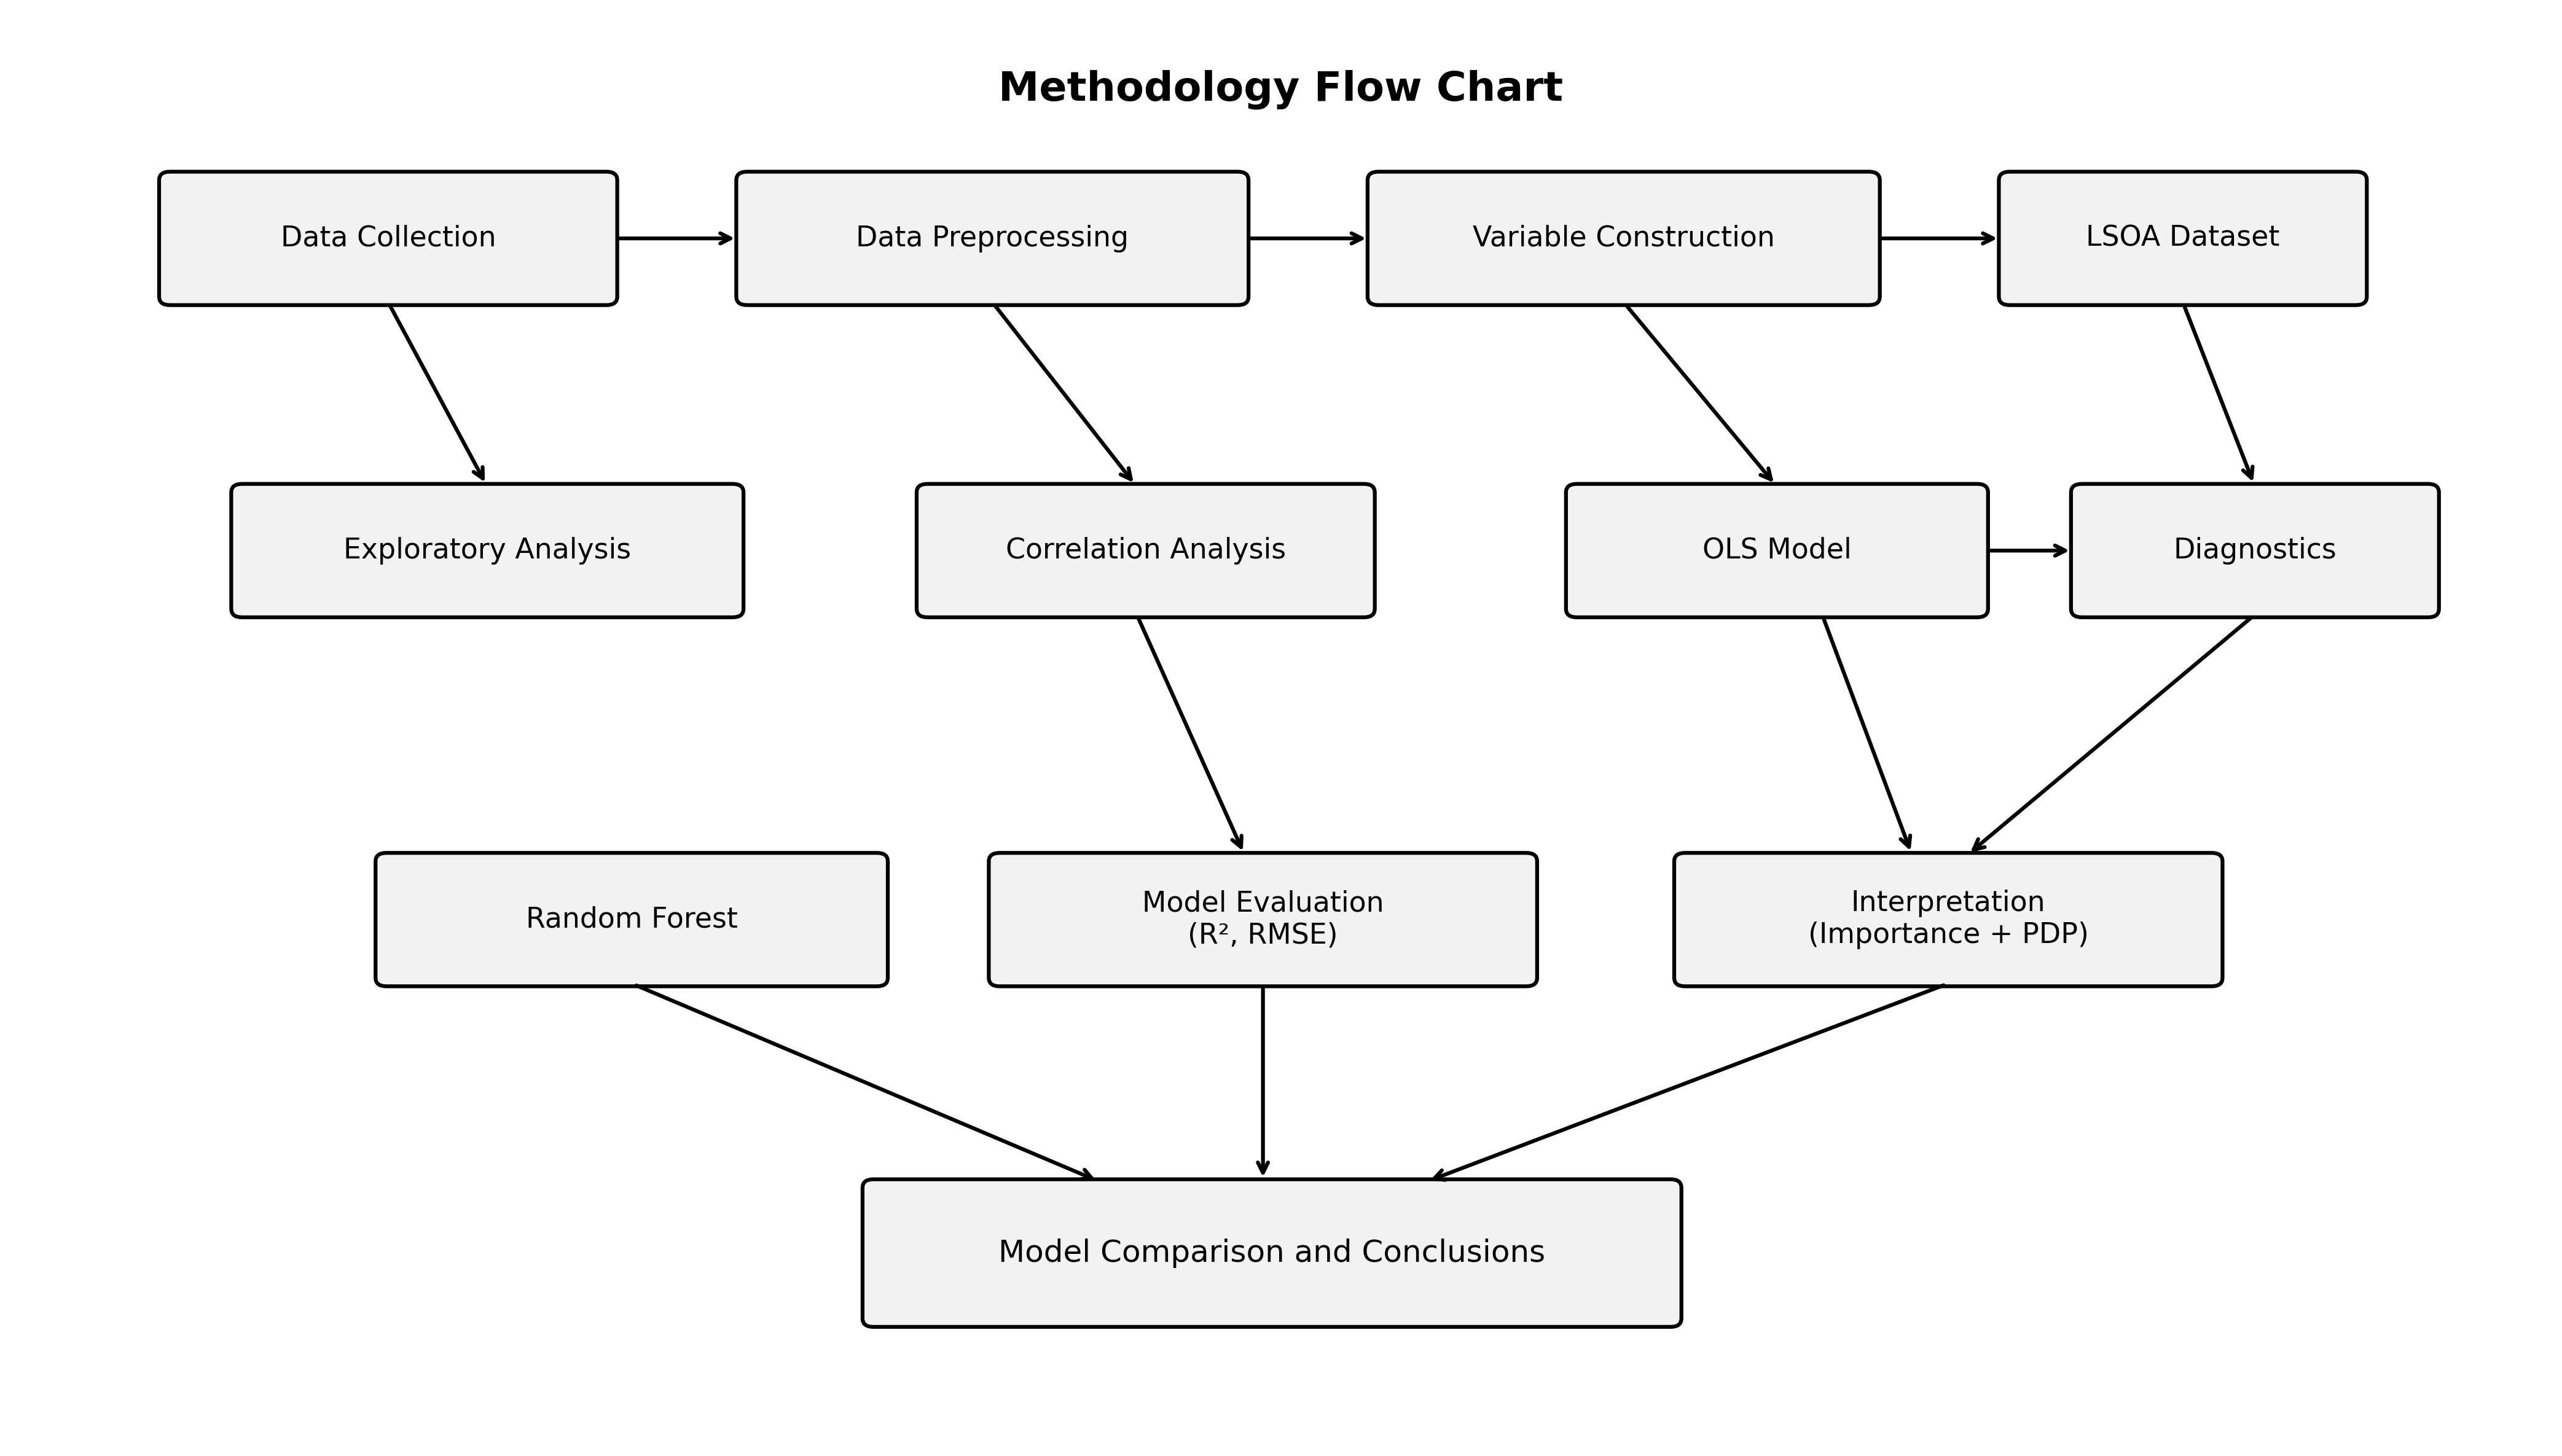

In [30]:
from IPython.display import Image, display

display(Image(filename="methodology_flowchart.png", width=850))

## Results and discussion [[ go back to the top ]](#Table-of-contents)
The results are presented by progressively examining the distribution, spatial structure, and socio-economic determinants of violent crime, in order to address the research question.
### Distribution of violent crime

The overall distribution of violent crime across LSOAs is first examined.

**Table 1. Summary statistics of variables used in the analysis**

In [31]:
# Summary statistics for key variables
summary_stats = analysis_df_final[
    [
        "violent_crime_rate",
        "imd_rev",
        "economic_inactivity_rate",
        "population_density",
        "overcrowding_rate"
    ]
].describe()

summary_stats.T

,count,mean,std,min,25%,50%,75%,max
violent_crime_rate,4653.0,26.305800,24.350443,0.675676,14.204545,21.854696,31.945789,756.357185
imd_rev,4653.0,17523.934666,8135.586486,282.000000,10952.000000,18587.000000,24589.000000,32299.000000
economic_inactivity_rate,4653.0,0.342497,0.065201,0.106764,0.301041,0.348473,0.385517,0.632878
population_density,4653.0,9962.327036,6089.489185,119.900000,5464.000000,8833.900000,13395.500000,55769.200000
overcrowding_rate,4653.0,0.110018,0.069251,0.000000,0.052388,0.097387,0.156863,0.392236


Table 1 presents summary statistics for the key variables used in the analysis. Violent crime rates have a mean of 26.31 and a median of 21.85, indicating a positively skewed distribution. The wide range of values (0.68–756.36) suggests substantial variation across LSOAs, with a small number of areas experiencing disproportionately high crime levels.

This uneven distribution indicates that violent crime is concentrated in a limited number of neighbourhoods, rather than evenly distributed across London.

**Figure 1: Distribution of violent crime rates (per 1,000 population) across London LSOAs**

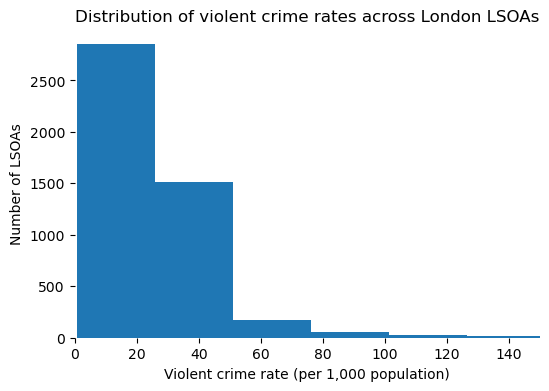

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.rcParams["font.size"] = 10

analysis_df_final["violent_crime_rate"].hist(bins=30)

plt.title("Distribution of violent crime rates across London LSOAs")
plt.xlabel("Violent crime rate (per 1,000 population)")
plt.ylabel("Number of LSOAs")

plt.xlim(0, 150)
plt.grid(False)
plt.box(False)

plt.show()

Figure 1 reinforces this pattern by showing a long right tail in the distribution of violent crime rates. This visual pattern confirms that while most LSOAs experience relatively low to moderate crime levels, a small number of areas exhibit substantially higher rates.

Such concentration suggests that violent crime is not randomly distributed, but instead clustered within specific neighbourhoods.This provides an initial indication that spatial processes may play a role in shaping crime patterns, which is explored further in the following section.

### Spatial distribution of violent crime

**Figure 2: Spatial distribution of violent crime rates (per 1,000 population) across London LSOAs**

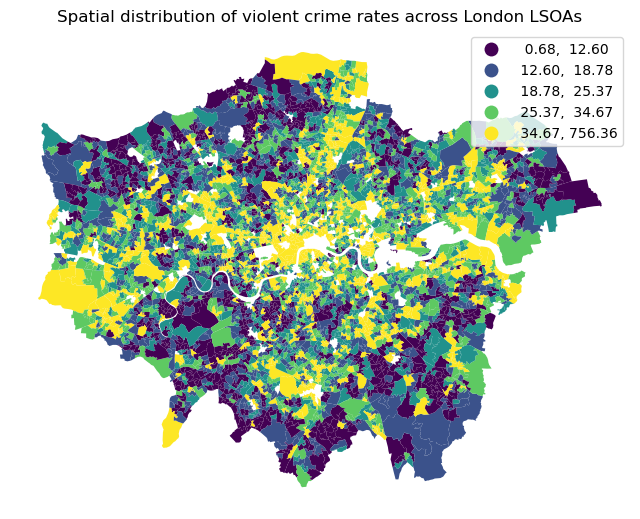

In [35]:
fig, ax = plt.subplots(figsize=(8, 8))

analysis_gdf.plot(
    column="violent_crime_rate",
    scheme="quantiles",
    k=5,
    legend=True,
    linewidth=0,
    ax=ax
)

ax.set_title("Spatial distribution of violent crime rates across London LSOAs")
ax.axis("off")

plt.show()

Figure 2 shows the spatial distribution of violent crime rates across London LSOAs. Higher crime rates are concentrated in particular areas of the city, forming visible clusters rather than being evenly distributed across space.

These patterns indicate that violent crime is spatially structured, with certain neighbourhoods consistently experiencing higher levels of crime. This highlights the presence of spatial clustering, suggesting that crime is influenced by underlying spatial processes.

This pattern is formally tested using spatial autocorrelation analysis in the following section.

### Correlation analysis

**Figure 3: Correlation matrix of violent crime and explanatory variables**


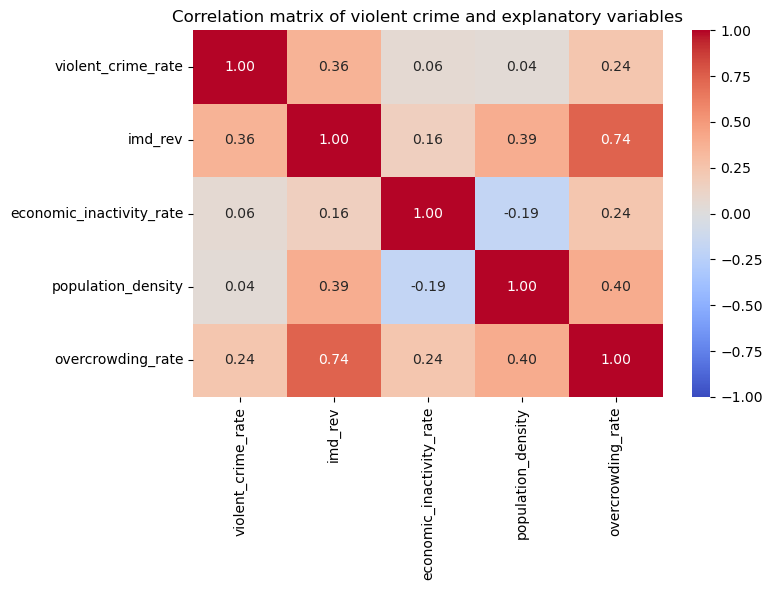

In [33]:
# Correlation analysis: compute correlation coefficients
correlation_matrix = analysis_df_final[
    [
        "violent_crime_rate",
        "imd_rev",
        "economic_inactivity_rate",
        "population_density",
        "overcrowding_rate"
    ]
].corr()

# Visualise the correlation structure
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Correlation matrix of violent crime and explanatory variables")
plt.tight_layout()
plt.show()

**Table 2: Correlation coefficients**


In [34]:
# Display the exact correlation coefficients
correlation_matrix

,violent_crime_rate,imd_rev,economic_inactivity_rate,population_density,overcrowding_rate
violent_crime_rate,1.000000,0.363644,0.055703,0.043344,0.241442
imd_rev,0.363644,1.000000,0.156493,0.390925,0.738649
economic_inactivity_rate,0.055703,0.156493,1.000000,-0.185948,0.240849
population_density,0.043344,0.390925,-0.185948,1.000000,0.401681
overcrowding_rate,0.241442,0.738649,0.240849,0.401681,1.000000


Table 2 reports the correlation coefficients between violent crime and the explanatory variables, while Figure 3 provides a visual representation of these relationships.

Deprivation (imd_rev) shows the strongest positive association with violent crime, indicating that areas with higher levels of socio-economic disadvantage tend to experience higher crime rates. This suggests that deprivation may play an important role in explaining variation in violent crime.

Other variables exhibit relatively weaker associations, although overcrowding shows a moderate positive correlation with violent crime. Correlations among explanatory variables are generally moderate, although the relatively high correlation between deprivation and overcrowding suggests potential overlap that should be considered in regression analysis.

Overall, these results identify deprivation as the most important associated factor and provide a basis for further modelling.

### Spatial autocorrelation
Spatial autocorrelation is assessed using Moran’s I based on a K-nearest neighbours (KNN) weights matrix (k = 5) to examine whether violent crime exhibits spatial clustering.

In [63]:
from libpysal.weights import KNN

# K-nearest neighbours weights
w = KNN.from_dataframe(analysis_gdf, k=5)
w.transform = "r"

print(w.n)
print(len(w.islands))

4653
0


#### Global spatial autocorrelation (Moran’s I) 

In [64]:
import numpy as np

y = analysis_gdf["violent_crime_rate"].to_numpy()
n = len(y)

def moran_stat(values, w):
    z = values - values.mean()
    S0 = w.s0
    num = 0.0
    for i, neighbors in w.neighbors.items():
        weights_i = w.weights[i]
        for idx, j in enumerate(neighbors):
            wij = weights_i[idx]
            num += wij * z[i] * z[j]
    den = np.sum(z ** 2)
    return (n / S0) * (num / den)

obs_I = moran_stat(y, w)

np.random.seed(42)
n_perm = 199
perm_I = np.array([moran_stat(np.random.permutation(y), w) for _ in range(n_perm)])

p_sim = (np.sum(perm_I >= obs_I) + 1) / (n_perm + 1)

print("Observed Moran's I:", obs_I)
print("Permutation p-value:", p_sim)

Observed Moran's I: 0.30074452994841167
Permutation p-value: 0.005


The Moran’s I value is 0.301 (p = 0.005), indicating significant positive spatial autocorrelation. Areas with high violent crime rates tend to be located near other high-crime areas, while low-crime areas are similarly clustered.

This confirms that violent crime is not randomly distributed across London, but instead exhibits clear spatial clustering, directly addressing RQ1. The presence of spatial autocorrelation also indicates that the assumption of independent observations may be violated, as neighbouring areas exhibit similar crime levels.

In substantive terms, this pattern indicates that violent crime is shaped by spatially structured processes, where nearby areas may share common socio-economic characteristics or be influenced by local spillover effects.

### Regression  (OLS)
**Table 3. OLS coefficient estimates**

In [61]:
import statsmodels.api as sm

X = analysis_gdf[
    [
        "imd_rev",
        "economic_inactivity_rate",
        "population_density",
        "overcrowding_rate"
    ]
].copy()

y = analysis_gdf["violent_crime_rate"].copy()

X = sm.add_constant(X)

ols_model = sm.OLS(y, X).fit()

ols_results = ols_model.summary2().tables[1]
ols_results

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,13.132185,2.040972,6.434281,1.365636e-10,9.130912,17.133458
imd_rev,0.001292,0.000061,21.205540,2.444406e-95,0.001173,0.001412
economic_inactivity_rate,-11.026314,5.505728,-2.002699,4.526760e-02,-21.820153,-0.232476
population_density,-0.000490,0.000063,-7.747854,1.139836e-14,-0.000613,-0.000366
overcrowding_rate,-7.459858,7.433285,-1.003575,3.156358e-01,-22.032623,7.112907


In [62]:
print("R-squared:", ols_model.rsquared)
print("Adjusted R-squared:", ols_model.rsquared_adj)

R-squared: 0.14494572794382643
Adjusted R-squared: 0.1442098808938641


An Ordinary Least Squares (OLS) model is estimated to examine the relationship between violent crime and socio-economic variables.

Deprivation (imd_rev) shows a strong positive association with violent crime, indicating that areas with higher levels of socio-economic disadvantage tend to experience higher crime rates. In contrast, economic inactivity and population density exhibit negative associations, indicating that higher values of these variables are associated with lower recorded crime rates. Overcrowding does not show a statistically meaningful relationship in this model.

Overall, the model explains a modest proportion of variation in violent crime (R² = 0.145), indicating that while socio-economic factors are relevant, they do not fully account for observed patterns. While the OLS model provides initial insights into the relationship, its reliability depends on whether key model assumptions are satisfied. To evaluate this, residual diagnostics are examined.


### Diagnostics

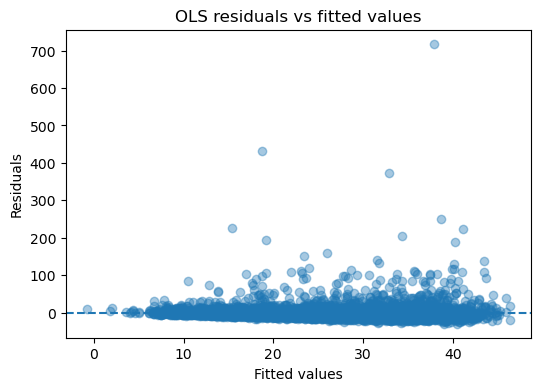

In [59]:
analysis_gdf["ols_fitted"] = ols_model.fittedvalues
analysis_gdf["ols_residuals"] = ols_model.resid

plt.figure(figsize=(6, 4))
plt.scatter(analysis_gdf["ols_fitted"], analysis_gdf["ols_residuals"], alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("OLS residuals vs fitted values")
plt.show()

**Figure 5. Residuals vs fitted values**

Figure 5 shows the relationship between residuals and fitted values. The dispersion of residuals increases with fitted values, indicating heteroskedasticity and a potential violation of the constant variance assumption. This pattern indicates that the model fit becomes less stable at higher levels of predicted crime.

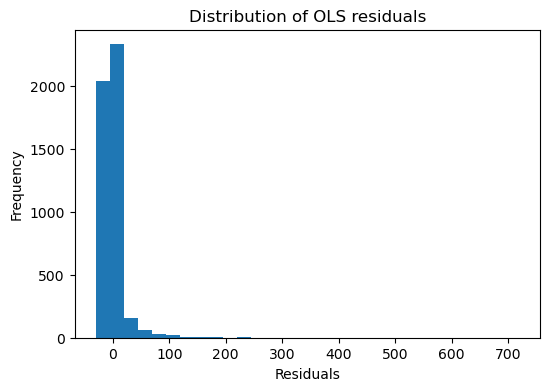

In [40]:
plt.figure(figsize=(6, 4))
plt.hist(analysis_gdf["ols_residuals"], bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of OLS residuals")
plt.show()

**Figure 6. Distribution of OLS residuals**

Figure 6 presents the distribution of residuals. The residuals are approximately centred around zero but exhibit noticeable skewness and a long tail, indicating the presence of outliers and large prediction errors for some observations.

Together, these diagnostic results indicate that key OLS assumptions are not fully satisfied. In particular, violations of homoscedasticity and deviations from normality indicate that the model errors are not well-behaved. This indicates that the linear specification is limited in capturing the full complexity of the relationship, providing justification for the use of more flexible modelling approaches in the following section.

### Random Forest
To capture potential non-linear relationships, a Random Forest model is applied.

**Model performance (Random Forest)**

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

X_ml = analysis_gdf[
    [
        "imd_rev",
        "economic_inactivity_rate",
        "population_density",
        "overcrowding_rate"
    ]
].copy().astype(float)

y_ml = analysis_gdf["violent_crime_rate"].copy().astype(float)


X_train, X_test, y_train, y_test = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Random Forest R²:", r2_score(y_test, y_pred))
print("Random Forest RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

Random Forest R²: 0.1559459458166903
Random Forest RMSE: 18.819048121774994


The Random Forest model achieves an R² of 0.156 and an RMSE of 18.82, which is similar to the OLS model (R² = 0.145), indicating only limited improvement in predictive performance. This suggests that the included socio-economic variables explain only a modest proportion of the variation in violent crime, and that additional factors not captured in the model are likely to play an important role.

**Figure 7. Feature importance (Random Forest)**

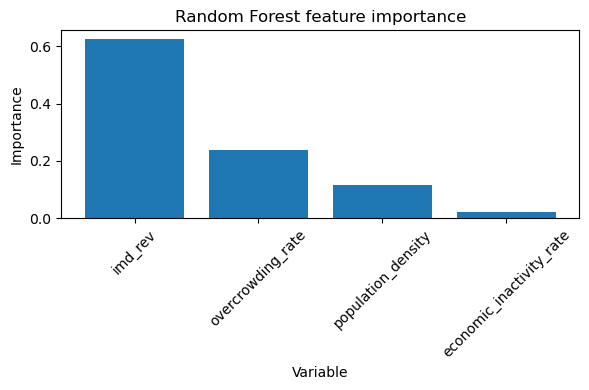

In [53]:
import pandas as pd

rf_importance = pd.DataFrame({
    "variable": X_ml.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(6, 4))
plt.bar(rf_importance["variable"], rf_importance["importance"])
plt.xticks(rotation=45)
plt.xlabel("Variable")
plt.ylabel("Importance")
plt.title("Random Forest feature importance")
plt.tight_layout()
plt.show()

Figure 7 presents the feature importance derived from the Random Forest model. Deprivation (imd_rev) is identified as the most influential predictor, followed by overcrowding, population density, and economic inactivity.

The dominant importance of deprivation indicates that variation in violent crime is primarily driven by underlying socio-economic disadvantage, rather than demographic or density-related factors. In contrast, the relatively lower importance of population density and economic inactivity suggests that these variables play a more limited role in explaining crime variation when considered alongside deprivation.

### PDP（non-linear）

However, the similar predictive performance does not imply that the underlying relationships are purely linear. Instead, it indicates that while the overall trend can be approximated by a linear model, additional non-linear patterns remain present, particularly at different levels of deprivation. This is further explored using partial dependence plots.

In [54]:
from sklearn.inspection import PartialDependenceDisplay

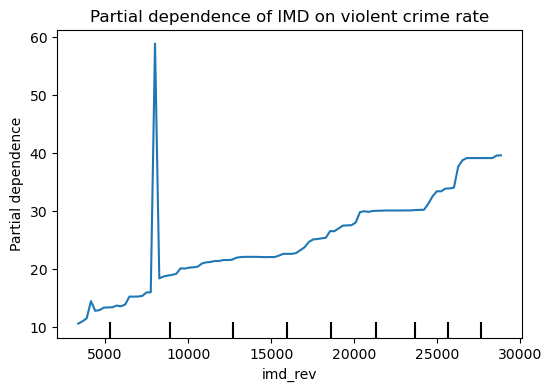

In [55]:
fig, ax = plt.subplots(figsize=(6, 4))
PartialDependenceDisplay.from_estimator(
    rf,
    X_train,
    ["imd_rev"],
    ax=ax
)
plt.title("Partial dependence of IMD on violent crime rate")
plt.show()

**Figure 8. Partial dependence plot for deprivation**

Figure 8 presents the partial dependence plot for deprivation. The relationship between deprivation and violent crime is non-linear, with a generally increasing trend that becomes steeper at higher levels of deprivation.

This pattern suggests the presence of a threshold effect, where increases in deprivation are associated with larger increases in crime beyond a certain level. The effect of deprivation therefore appears to strengthen at higher values rather than remaining constant across its range.

Overall, although the Random Forest model does not substantially improve predictive performance compared to OLS, it reveals non-linear structure in the relationship between deprivation and violent crime that is not captured by a linear model.

### Discussion and limitations
The findings indicate that violent crime in London is not randomly distributed but exhibits clear spatial clustering, with higher crime rates concentrated in specific areas. This pattern reflects broader urban inequalities, where socio-economic conditions are unevenly distributed across neighbourhoods (Sampson et al., 1997). It also suggests that spatial dependence may influence regression results, potentially violating the independence assumption of OLS and affecting the reliability of coefficient estimates. This indicates that spatial processes are not fully captured in the current modelling framework, suggesting that spatial regression approaches could provide more robust estimates.

Deprivation emerges as a key factor associated with violent crime across both regression and machine learning analyses. Areas characterised by higher levels of socio-economic disadvantage tend to experience higher crime rates, which is consistent with previous research linking inequality and crime (Fajnzylber et al., 2002; Kelly, 2000). Structural constraints such as limited economic opportunities, housing stress, and reduced social cohesion may increase the likelihood of violence, indicating that violent crime is embedded within broader structural inequalities shaping urban environments.

The machine learning results further demonstrate that this relationship is not strictly linear. The effect of deprivation becomes noticeably stronger at higher levels, indicating the presence of threshold dynamics where increases in disadvantage lead to disproportionately higher crime rates. This suggests that linear models may underestimate the impact of deprivation in highly disadvantaged areas, highlighting the importance of considering non-linear relationships in urban crime analysis.

Although the Random Forest model does not substantially outperform OLS in predictive accuracy, it provides additional insights into complex relationships that are not captured by linear models (Breiman, 2001). This highlights the value of machine learning as a complementary approach rather than a replacement for traditional statistical methods. However, the limited improvement in predictive performance also suggests that non-linearity alone may not fully explain crime patterns, indicating the potential role of additional unobserved factors.

Despite these insights, several limitations should be acknowledged. First, the explanatory power of both models is relatively modest, suggesting the presence of omitted variable bias and that important factors influencing violent crime may not be included. Second, spatial dependence is not explicitly modelled, which may affect the robustness of regression estimates. Third, the use of cross-sectional data limits the ability to capture temporal dynamics and restricts causal interpretation.

Overall, the results suggest that violent crime in London is shaped by a combination of socio-economic conditions and spatial processes. This suggests that socio-economic deprivation does not operate in isolation, but interacts with spatial processes, where concentrated disadvantage may reinforce local crime dynamics through neighbourhood effects and cumulative pressures.

## Conclusion

This study examined the spatial distribution of violent crime in London and its relationship with socio-economic factors. The results show that violent crime is spatially clustered and closely associated with deprivation, supporting the role of structural inequalities in shaping urban crime patterns.

The analysis further demonstrates that this relationship is not strictly linear. The stronger impact of deprivation at higher levels suggests the presence of threshold effects, where increases in disadvantage lead to disproportionately higher crime rates.

Overall, the findings indicate that violent crime in London is influenced by both socio-economic conditions and spatial processes, with deprivation playing a central and potentially non-linear role.

## References
Anselin, L. (1995) 'Local indicators of spatial association—LISA', Geographical Analysis, 27(2), pp. 93–115.

Breiman, L. (2001) 'Random forests', Machine Learning, 45(1), pp. 5–32.

Dormann, C.F., Elith, J., Bacher, S., Buchmann, C., Carl, G., Carré, G., García Márquez, J.R., Gruber, B., Lafourcade, B., Leitão, P.J., Münkemüller, T., McClean, C., Osborne, P.E., Reineking, B., Schröder, B., Skidmore, A.K., Zurell, D. and Lautenbach, S. (2013) 'Collinearity: a review of methods to deal with it and a simulation study evaluating their performance', Ecography, 36(1), pp. 27–46.

Fajnzylber, P., Lederman, D. and Loayza, N. (2002) 'Inequality and violent crime', Journal of Law and Economics, 45(1), pp. 1–40.

Greater London Authority (2024) MPS recorded crime: geographic breakdown. London: London Datastore. Available at: https://data.london.gov.uk/dataset/mps-recorded-crime-geographic-breakdown-exy3m/ (Accessed: 10 April 2026).

Kelly, M. (2000) 'Inequality and crime', Review of Economics and Statistics, 82(4), pp. 530–539.

Ministry of Housing, Communities and Local Government (2019) English indices of deprivation 2019. London: Ministry of Housing, Communities and Local Government. Available at: https://www.gov.uk/government/statistics/english-indices-of-deprivation-2019 (Accessed: 10 April 2026).

Molnar, C. (2022) Interpretable machine learning: a guide for making black box models explainable. 2nd edn. Self-published. Available at: https://christophm.github.io/interpretable-ml-book/ (Accessed: 10 April 2026).

Office for National Statistics (2011) 2011 census geography boundaries: lower layer super output areas. Newport: Office for National Statistics. Available at: https://geoportal.statistics.gov.uk (Accessed: 10 April 2026).

Sampson, R.J., Raudenbush, S.W. and Earls, F. (1997) 'Neighbourhoods and violent crime: a multilevel study of collective efficacy', Science, 277(5328), pp. 918–924.

